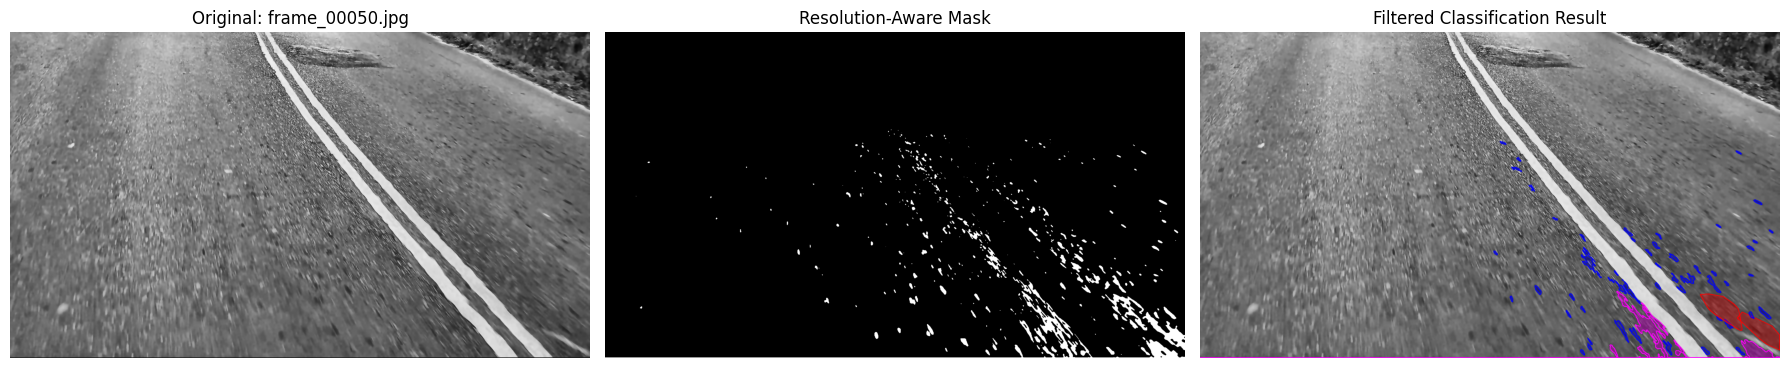

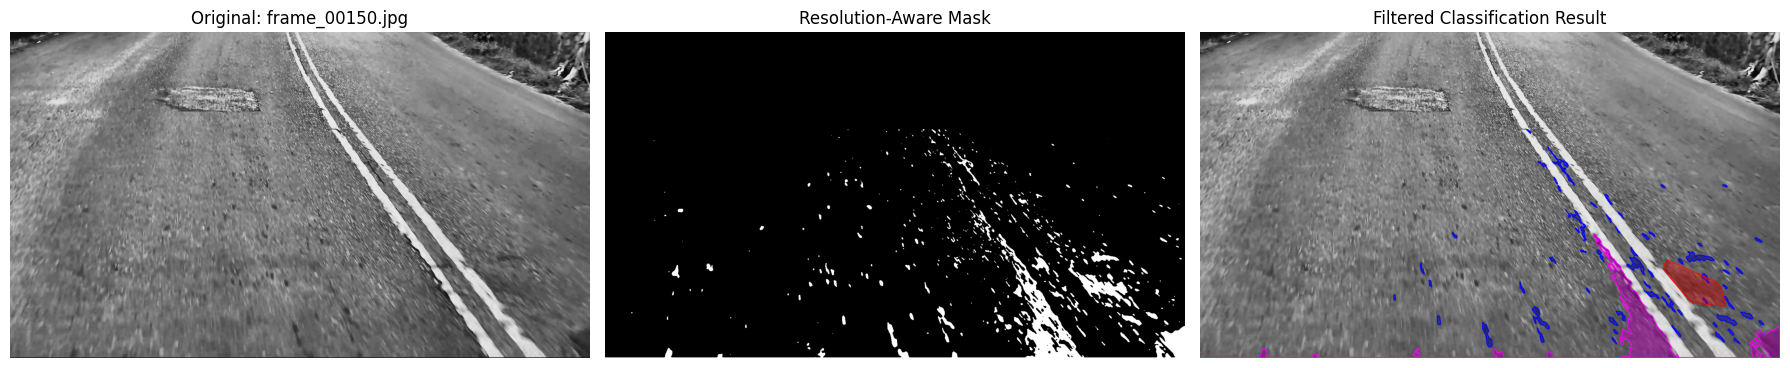

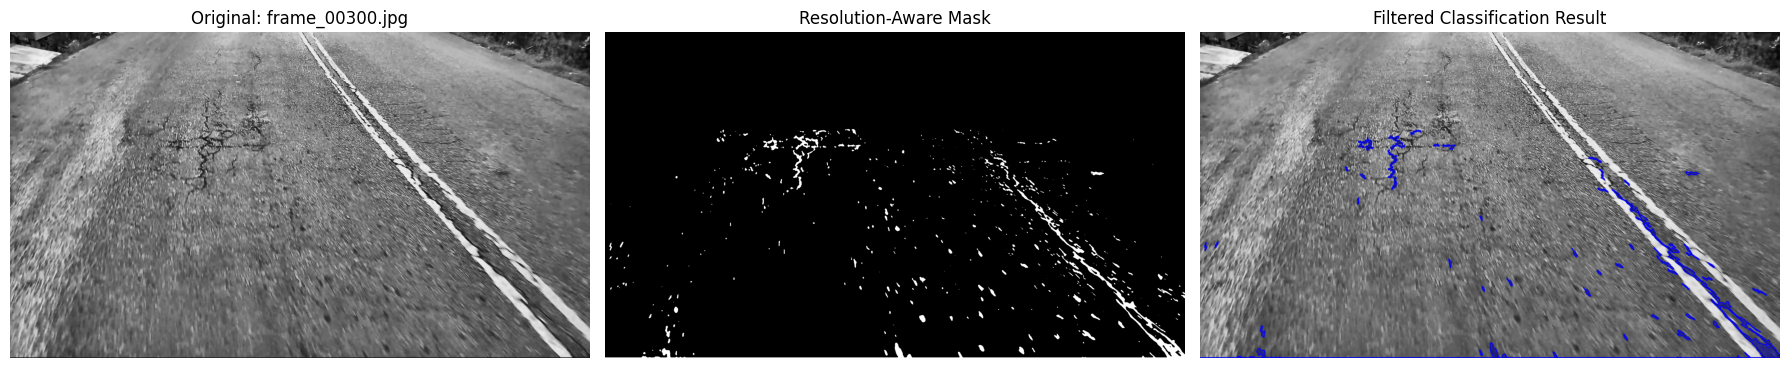

Visualization complete.


In [ ]:
# This notebook segments road damage and labels the damage type.
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Use enhanced frames as input.
input_dir = 'enhanced_frames/' 
test_frames = ["frame_00050.jpg", "frame_00150.jpg", "frame_00300.jpg"]

# Build a binary mask for likely damage areas.
def segment_frame(img):
    h, w = img.shape[:2]
    # Convert color images to gray.
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
        
    # Start with an empty mask.
    mask = np.zeros_like(gray)

    # Keep only the road area in the lower image.
    roi = np.array([[(int(w*0), int(h*1)), 
                     (int(w*0), int(h*0.5)),
                     (int(w*0.1), int(h*0.30)),
                     (int(w*0.9), int(h*0.30)), 
                     (int(w*1), int(h*0.5)),
                     (int(w*1), int(h*1))]], np.int32)
    cv2.fillPoly(mask, roi, 255)

    # Apply the road-area mask.
    masked = cv2.bitwise_and(gray, mask)
    road_pixels = gray[mask == 255]

    if len(road_pixels) == 0: 
        return mask
        
    # Use road brightness to choose a threshold.
    mu, sigma = np.mean(road_pixels), np.std(road_pixels)
    
    dynamic_multiplier = np.clip(sigma / 25.0, 0.8, 1.8)
    dyn_thresh = int(mu - (dynamic_multiplier * sigma))
    dyn_thresh = max(10, min(180, dyn_thresh))

    # Mark darker damage areas as white.
    _, binary = cv2.threshold(masked, dyn_thresh, 255, cv2.THRESH_BINARY_INV)
    binary = cv2.bitwise_and(binary, mask)
    
    # Remove tiny noise from the mask.
    k_blur = max(3, int(w * 0.003))
    k_blur = k_blur + 1 if k_blur % 2 == 0 else k_blur
    binary = cv2.medianBlur(binary, k_blur) 
    
    return binary
 
# Classify each detected damage shape.
def classify_damage(img, mask):
    h, w = img.shape[:2]
    total_pixels = h * w
    
    # Set size limits based on image size.
    noise_threshold = total_pixels * 0.00003     
    small_crack_limit = total_pixels * 0.0003    
    pothole_min_area = total_pixels * 0.0015     
    alligator_min_area = total_pixels * 0.001    

    # Find separate damage regions.
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    detection = img.copy()
    overlay = img.copy()

    for cnt in contours:
        # Measure the region size.
        area = cv2.contourArea(cnt)
        # Ignore very small noise.
        if area < noise_threshold: continue 

        # Measure the shape direction and width.
        rect = cv2.minAreaRect(cnt)
        (width_rect, height_rect) = rect[1]
        
        if width_rect == 0 or height_rect == 0: continue
        
        aspect_ratio = max(width_rect, height_rect) / min(width_rect, height_rect)

        if area < small_crack_limit and aspect_ratio < 2.5:
            continue

        # Measure shape solidity and roundness.
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        h_perim = cv2.arcLength(hull, True)
        h_circ = (4 * np.pi * hull_area) / (h_perim**2) if h_perim > 0 else 0

        # Measure how spread out the region is.
        data = cnt.reshape(-1, 2).astype(np.float64)
        if len(data) > 3:
            _, _, evals = cv2.PCACompute2(data, mean=None)
            ev1, ev2 = evals[0][0], (evals[1][0] if len(evals) > 1 else 0)
            spread_ratio = ev2 / ev1 if ev1 > 0 else 0
        else:
            spread_ratio = 0

        # Pick a color based on damage shape.
        if area > pothole_min_area and h_circ > 0.50 and solidity > 0.40:
            color, draw_cnt = (0, 0, 255), hull      # Pothole (Red)
        elif area > alligator_min_area and spread_ratio > 0.10 and solidity < 0.65:
            color, draw_cnt = (255, 0, 255), cnt     # Alligator (Purple)
        else:
            color, draw_cnt = (255, 0, 0), cnt       # Logititude Crack (Blue)
            
        # Draw the result on the output image.
        cv2.drawContours(overlay, [draw_cnt], -1, color, -1)
        cv2.drawContours(detection, [draw_cnt], -1, color, 2)

    return cv2.addWeighted(overlay, 0.35, detection, 0.65, 0), mask

# Test the detector on selected frames.
for f_name in test_frames:
    img_path = os.path.join(input_dir, f_name)
    img = cv2.imread(img_path)
    
    # Skip missing test frames.
    if img is None:
        print(f"Skipping {f_name}: Not found in {input_dir}")
        continue

    # Segment the frame first.
    mask_result = segment_frame(img)
    
    # Classify the segmented regions.
    detection_img, final_mask = classify_damage(img, mask_result)

    # 3. Plot
    # Show the input, mask, and final result.
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Original: {f_name}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_result, cmap='gray')
    plt.title("Resolution-Aware Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(detection_img, cv2.COLOR_BGR2RGB))
    plt.title("Filtered Classification Result")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

print("Visualization complete.")